In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import mean_absolute_error, mean_squared_error
from datetime import datetime
import warnings
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score


warnings.filterwarnings("ignore")
sns.set_theme(style="darkgrid")

# Teams

In [2]:
home= "Auxerre"
away= "Strasbourg"

In [3]:
df_home= pd.read_csv(f"../Data/{home}.csv")
df_home["Date"] = pd.to_datetime(df_home["Date"]) 
df_home.tail()

,Team,Opp,Date,Result,H/A,GF,GA,GD,Poss,PKatt,...,xAG,xA,G-xG,np:G-xG,A-xAG,npxG/Sh,FKAtt,PSxG,PSxG/SoT,PSxG+/-
18,Auxerre,Saint-Étienne,2025-01-24,D,H,1,1,0,37,0,...,0.8,0.6,0.2,0.2,0.2,0.08,0,1.0,0.43,0.0
19,Auxerre,Monaco,2025-02-01,L,A,2,4,-2,43,1,...,0.6,0.6,0.8,0.3,0.4,0.06,0,4.1,0.68,0.1
20,Auxerre,Toulouse,2025-02-09,D,H,2,2,0,53,0,...,0.9,0.5,1.1,1.1,1.1,0.10,0,1.3,0.42,-0.7
21,Auxerre,Brest,2025-02-14,D,A,2,2,0,36,0,...,0.9,0.9,0.8,0.8,0.1,0.11,1,2.0,0.34,0.0
22,Auxerre,Marseille,2025-02-22,W,H,3,0,3,21,1,...,0.8,0.7,1.0,0.8,1.2,0.15,0,0.2,0.11,0.2


In [4]:
df_vs_home= pd.read_csv(f"../Data/vs {home}.csv")
df_vs_home["Date"] = pd.to_datetime(df_vs_home["Date"]) 
df_vs_home.tail()

,Team,Opp,Date,Result,H/A,GF,GA,GD,Poss,PKatt,...,xAG,xA,G-xG,np:G-xG,A-xAG,npxG/Sh,FKAtt,PSxG,PSxG/SoT,PSxG+/-
18,Saint-Étienne,Auxerre,2025-01-24,D,A,1,1,0,63,0,...,0.2,0.6,-0.2,-0.2,-0.2,0.18,1,1.4,0.28,0.4
19,Monaco,Auxerre,2025-02-01,W,H,4,2,2,57,0,...,2.5,1.5,1.4,1.4,0.5,0.24,1,2.6,0.33,0.6
20,Toulouse,Auxerre,2025-02-09,D,A,2,2,0,47,0,...,0.9,1.1,1.1,1.1,1.1,0.13,0,0.8,0.26,-1.2
21,Brest,Auxerre,2025-02-14,D,H,2,2,0,64,0,...,1.6,1.3,-0.2,-0.2,-0.6,0.12,0,1.4,0.23,-0.6
22,Marseille,Auxerre,2025-02-22,L,A,0,3,-3,79,0,...,0.4,1.2,-0.7,-0.7,-0.4,0.08,0,2.7,0.36,-0.3


In [5]:
df_away= pd.read_csv(f"../Data/{away}.csv")
df_away["Date"] = pd.to_datetime(df_away["Date"]) 
df_away.tail()

,Team,Opp,Date,Result,H/A,GF,GA,GD,Poss,PKatt,...,xAG,xA,G-xG,np:G-xG,A-xAG,npxG/Sh,FKAtt,PSxG,PSxG/SoT,PSxG+/-
18,Strasbourg,Lille,2025-01-25,W,H,2,1,1,42,0,...,1.0,1.1,0.9,0.9,0.0,0.10,0,2.3,0.38,1.3
19,Strasbourg,Rennes,2025-02-02,L,A,0,1,-1,54,0,...,1.2,0.8,-1.2,-1.2,-1.2,0.17,0,1.2,0.41,0.2
20,Strasbourg,Montpellier,2025-02-09,W,H,2,0,2,59,0,...,1.7,1.6,-0.7,-0.7,-0.7,0.14,1,0.1,0.06,0.1
21,Strasbourg,Lens,2025-02-16,W,A,2,0,2,44,0,...,2.0,1.3,-0.4,-0.4,0.0,0.18,0,0.0,NaN,0.0
22,Strasbourg,Brest,2025-02-23,D,H,0,0,0,57,0,...,0.4,1.0,-0.6,-0.6,-0.4,0.20,0,0.1,0.07,0.1


In [6]:
df_vs_away= pd.read_csv(f"../Data/vs {away}.csv")
df_vs_away["Date"] = pd.to_datetime(df_away["Date"]) 
df_vs_away.tail()

,Team,Opp,Date,Result,H/A,GF,GA,GD,Poss,PKatt,...,xAG,xA,G-xG,np:G-xG,A-xAG,npxG/Sh,FKAtt,PSxG,PSxG/SoT,PSxG+/-
18,Lille,Strasbourg,2025-01-25,L,A,1,2,-1,58,0,...,1.7,1.4,-0.8,-0.8,-0.7,0.12,0,2.2,0.32,0.2
19,Rennes,Strasbourg,2025-02-02,W,H,1,0,1,46,0,...,0.7,0.7,0.1,0.1,-0.7,0.07,0,0.7,0.25,0.7
20,Montpellier,Strasbourg,2025-02-09,L,A,0,2,-2,41,0,...,1.8,1.1,-1.8,-1.8,-1.8,0.17,1,1.7,0.40,-0.3
21,Lens,Strasbourg,2025-02-16,L,H,0,2,-2,56,0,...,0.3,1.2,-0.4,-0.4,-0.3,0.05,0,2.1,0.53,0.1
22,Brest,Strasbourg,2025-02-23,D,A,0,0,0,43,0,...,0.5,0.5,-0.6,-0.6,-0.5,0.05,0,0.3,0.31,0.3


In [7]:
print(list(df_away.columns))

['Team', 'Opp', 'Date', 'Result', 'H/A', 'GF', 'GA', 'GD', 'Poss', 'PKatt', 'G-PK', 'PK', 'PKm', 'Att (GK)', 'Thr', 'Pa Launch%', 'Pa AvgLen', 'Won', 'Lost', 'Won%', 'Att To', 'Succ', 'Succ%', 'Tkld', 'Tkld%', 'Carries', 'TotDist', 'PrgDist', 'PrgC', 'Last3rd Car', 'OppCr', 'Stp', 'Stp%', 'CrdY', 'CrdR', '2CrdY', 'Fls', 'Fld', 'GCA', 'PassLive Gc', 'PassDead Gc', 'TO Gc', 'Sh-Gc', 'Fld Gc', 'Def-Gc', 'GK Att', 'Launch%', 'AvgLen', 'Sh', 'G/Sh', 'G/SoT', 'SoT', 'SoT%', 'Dist', 'FK', 'Off', 'PKwon', 'PKcon', 'OG', 'Recov', '#OPA', 'AvgDist', 'Cmp', 'Pas Att', 'Cmp%', 'KP', 'Last3rd PA', 'PPA', 'CrsPA', 'PrgP', 'TotDist Pas', 'PrgDist Pas', 'Cmp 5-15', 'Att 5-15', 'Cmp% 5-15', 'Cmp 15-30', 'Att 15-30', 'Cmp% 15-30', 'Cmp 30+', 'Att 30+', 'Cmp% 30+', 'PKdef', 'PKA', 'PKms', 'Missed PK%', 'PKAg', 'PKsv', 'PK Save%', 'FK Ag', 'CKG', 'OGK', 'Live Pas', 'Dead', 'Pas FK', 'TB', 'Sw', 'Crs', 'TI', 'CK', 'In', 'Out', 'Str', 'Ps Off', 'PTo', 'Rec', 'Last3rd Rec', 'CPA', 'Mis', 'Dis', 'SCA', 'PassL

# Desc

# Features

## Offense

In [8]:
offense= ['G-PK', 'PK', 'PKm', 'Poss', 'PKatt', 'Att To', 'Succ', 'Succ%', 'Tkld', 'Tkld%', 'Carries', 'TotDist', 'PrgDist', 
          'PrgC', 'Last3rd Car', 'GCA', 'PassLive Gc', 'PassDead Gc', 'TO Gc', 'Sh-Gc', 'Fld Gc', 'Def-Gc', 'Sh', 'G/Sh', 
          'G/SoT', 'SoT', 'SoT%', 'Dist', 'FK', 'Off', 'PKwon', 'Cmp', 'Pas Att', 'Cmp%', 'KP', 'Last3rd PA', 'PPA', 'CrsPA', 
          'PrgP', 'TotDist Pas', 'PrgDist Pas', 'Cmp 5-15', 'Att 5-15', 'Cmp% 5-15', 'Cmp 15-30', 'Att 15-30', 'Cmp% 15-30', 
          'Cmp 30+', 'Att 30+', 'Cmp% 30+', 'Live Pas', 'Dead', 'Pas FK', 'TB', 'Sw', 'Crs', 'TI', 'CK', 'In', 'Out', 'Str', 
          'Ps Off', 'PTo', 'Rec', 'Last3rd Rec', 'CPA', 'Mis', 'Dis', 'SCA', 'PassLive Sc', 'PassDead Sc', 'TO Sc', 'Sh-Sh', 
          'Fld Sc', 'Def-Sc', 'Touches', 'Def Pen', 'Tch Def 3rd', 'Tch Mid 3rd', 'Tch Att 3rd', 'Att Pen', 'Live Tch', 'xG', 
          'npxG', 'xGD', 'npxGD', 'xAG', 'xA', 'G-xG', 'np:G-xG', 'A-xAG', 'npxG/Sh', 'FKAtt', 'GF']

In [9]:
df_home_off= df_home[offense]
df_home_off.tail()

,G-PK,PK,PKm,Poss,PKatt,Att To,Succ,Succ%,Tkld,Tkld%,...,xGD,npxGD,xAG,xA,G-xG,np:G-xG,A-xAG,npxG/Sh,FKAtt,GF
18,1,0,0,37,0,17,9,52.9,8,47.1,...,-0.3,-0.3,0.8,0.6,0.2,0.2,0.2,0.08,0,1
19,1,1,0,43,1,21,3,14.3,14,66.7,...,-1.4,-2.0,0.6,0.6,0.8,0.3,0.4,0.06,0,2
20,2,0,0,53,0,18,8,44.4,10,55.6,...,0.0,0.0,0.9,0.5,1.1,1.1,1.1,0.10,0,2
21,2,0,0,36,0,12,5,41.7,7,58.3,...,-1.0,-1.0,0.9,0.9,0.8,0.8,0.1,0.11,1,2
22,2,1,0,21,1,18,7,38.9,9,50.0,...,1.3,0.5,0.8,0.7,1.0,0.8,1.2,0.15,0,3


In [10]:
df_vs_home_off= df_vs_home[offense]
df_vs_home_off.tail()

,G-PK,PK,PKm,Poss,PKatt,Att To,Succ,Succ%,Tkld,Tkld%,...,xGD,npxGD,xAG,xA,G-xG,np:G-xG,A-xAG,npxG/Sh,FKAtt,GF
18,1,0,0,63,0,14,3,21.4,9,64.3,...,0.3,0.3,0.2,0.6,-0.2,-0.2,-0.2,0.18,1,1
19,4,0,0,57,0,16,5,31.3,10,62.5,...,1.4,2.0,2.5,1.5,1.4,1.4,0.5,0.24,1,4
20,2,0,0,47,0,10,4,40.0,6,60.0,...,0.0,0.0,0.9,1.1,1.1,1.1,1.1,0.13,0,2
21,2,0,0,64,0,15,5,33.3,9,60.0,...,1.0,1.0,1.6,1.3,-0.2,-0.2,-0.6,0.12,0,2
22,0,0,0,79,0,18,5,27.8,13,72.2,...,-1.3,-0.5,0.4,1.2,-0.7,-0.7,-0.4,0.08,0,0


In [11]:
df_away_off= df_away[offense]
df_away_off.tail()

,G-PK,PK,PKm,Poss,PKatt,Att To,Succ,Succ%,Tkld,Tkld%,...,xGD,npxGD,xAG,xA,G-xG,np:G-xG,A-xAG,npxG/Sh,FKAtt,GF
18,2,0,0,42,0,16,6,37.5,8,50.0,...,-0.7,-0.7,1.0,1.1,0.9,0.9,0.0,0.10,0,2
19,0,0,0,54,0,18,7,38.9,10,55.6,...,0.3,0.3,1.2,0.8,-1.2,-1.2,-1.2,0.17,0,0
20,2,0,0,59,0,18,9,50.0,8,44.4,...,1.0,1.0,1.7,1.6,-0.7,-0.7,-0.7,0.14,1,2
21,2,0,0,44,0,16,8,50.0,7,43.8,...,2.0,2.0,2.0,1.3,-0.4,-0.4,0.0,0.18,0,2
22,0,0,0,57,0,14,7,50.0,5,35.7,...,0.0,0.0,0.4,1.0,-0.6,-0.6,-0.4,0.20,0,0


In [12]:
df_vs_away_off= df_vs_away[offense]
df_vs_away_off.tail()

,G-PK,PK,PKm,Poss,PKatt,Att To,Succ,Succ%,Tkld,Tkld%,...,xGD,npxGD,xAG,xA,G-xG,np:G-xG,A-xAG,npxG/Sh,FKAtt,GF
18,1,0,0,58,0,10,7,70.0,3,30.0,...,0.7,0.7,1.7,1.4,-0.8,-0.8,-0.7,0.12,0,1
19,1,0,0,46,0,13,6,46.2,6,46.2,...,-0.3,-0.3,0.7,0.7,0.1,0.1,-0.7,0.07,0,1
20,0,0,0,41,0,15,9,60.0,5,33.3,...,-1.0,-1.0,1.8,1.1,-1.8,-1.8,-1.8,0.17,1,0
21,0,0,0,56,0,15,4,26.7,10,66.7,...,-2.0,-2.0,0.3,1.2,-0.4,-0.4,-0.3,0.05,0,0
22,0,0,0,43,0,15,6,40.0,7,46.7,...,0.0,0.0,0.5,0.5,-0.6,-0.6,-0.5,0.05,0,0


## Defence

In [13]:
defence= ['OppCr', 'Stp', 'Stp%', 'PKcon', '#OPA', 'AvgDist', 'PKsv', 'PK Save%', 'FK Ag', 'CKG', 'OGK', 'SoTA', 'Saves', 
          'Save%', 'Tkl', 'TklW', 'Tkl Def 3rd', 'Tkl Mid 3rd', 'Tkl Att 3rd', 'Tkl.2', 'Tkl Att', 'Tkl%', 'Lost Tkl', 
          'Ints', 'BlcSh', 'Pass', 'Int', 'Tkl+Int', 'Clr', 'Err',  'PSxG', 'PSxG/SoT', 'PSxG+/-', 'GA']

In [14]:
df_home_def= df_home[defence]
df_home_def.tail()

,OppCr,Stp,Stp%,PKcon,#OPA,AvgDist,PKsv,PK Save%,FK Ag,CKG,...,BlcSh,Pass,Int,Tkl+Int,Clr,Err,PSxG,PSxG/SoT,PSxG+/-,GA
18,7,2,28.6,0,4,20.4,0,NaN,0,0,...,3,11,14,40,32,1,1.0,0.43,0.0,1
19,9,1,11.1,0,8,19.3,0,NaN,0,1,...,1,16,13,35,30,0,4.1,0.68,0.1,4
20,13,0,0.0,0,0,14.0,0,NaN,0,1,...,2,12,10,29,25,0,1.3,0.42,-0.7,2
21,25,0,0.0,0,2,18.5,0,NaN,0,0,...,5,8,10,32,41,1,2.0,0.34,0.0,2
22,12,2,16.7,0,2,15.8,0,NaN,0,0,...,2,3,7,33,35,0,0.2,0.11,0.2,0


In [15]:
df_vs_home_def= df_vs_home[defence]
df_vs_home_def.tail()

,OppCr,Stp,Stp%,PKcon,#OPA,AvgDist,PKsv,PK Save%,FK Ag,CKG,...,BlcSh,Pass,Int,Tkl+Int,Clr,Err,PSxG,PSxG/SoT,PSxG+/-,GA
18,8,0,0.0,0,0,10.7,0,NaN,0,0,...,1,11,9,27,18,0,1.4,0.28,0.4,1
19,10,0,0.0,1,2,17.2,0,0.0,0,0,...,0,12,13,41,15,0,2.6,0.33,0.6,2
20,9,1,11.1,0,2,18.0,0,NaN,0,1,...,3,6,11,34,22,0,0.8,0.26,-1.2,2
21,6,0,0.0,0,3,20.1,0,NaN,0,0,...,3,3,8,28,21,1,1.4,0.23,-0.6,2
22,11,0,0.0,1,3,23.4,0,0.0,0,1,...,1,4,0,13,18,1,2.7,0.36,-0.3,3


In [16]:
df_away_def= df_away[defence]
df_away_def.head()

,OppCr,Stp,Stp%,PKcon,#OPA,AvgDist,PKsv,PK Save%,FK Ag,CKG,...,BlcSh,Pass,Int,Tkl+Int,Clr,Err,PSxG,PSxG/SoT,PSxG+/-,GA
0,17,2,11.8,1,0,11.0,0,0.0,0,0,...,2,2,8,32,17,0,1.9,0.19,0.9,1
1,13,0,0.0,0,3,12.0,0,NaN,0,0,...,3,4,7,28,27,0,1.0,0.21,0.0,1
2,18,0,0.0,0,0,7.5,0,NaN,0,0,...,6,11,7,25,22,0,3.8,0.32,-0.2,4
3,20,0,0.0,0,1,13.8,0,NaN,0,0,...,5,11,8,29,29,0,1.0,0.50,0.0,1
4,22,3,13.6,1,0,4.5,0,0.0,0,0,...,2,7,14,23,26,1,2.3,0.26,-0.7,3


In [17]:
df_vs_away_def= df_vs_away[defence]
df_vs_away_def.head()

,OppCr,Stp,Stp%,PKcon,#OPA,AvgDist,PKsv,PK Save%,FK Ag,CKG,...,BlcSh,Pass,Int,Tkl+Int,Clr,Err,PSxG,PSxG/SoT,PSxG+/-,GA
0,9,0,0.0,0,2,17.8,0,NaN,0,0,...,1,6,3,25,12,0,1.5,0.39,0.5,1
1,7,0,0.0,0,0,2.0,0,NaN,0,1,...,3,9,11,30,10,0,1.4,0.28,-0.6,3
2,7,2,28.6,0,0,10.0,0,NaN,0,1,...,5,12,8,28,8,2,3.5,0.43,0.5,3
3,11,1,9.1,0,0,8.4,0,NaN,0,0,...,1,5,9,34,18,2,2.5,0.50,1.5,1
4,6,0,0.0,0,0,NaN,0,NaN,0,0,...,2,3,4,21,10,1,3.0,0.37,0.0,3


## Combined

In [18]:
combined= ['Won', 'Lost', 'Won%', 'CrdY', 'CrdR', '2CrdY', 'Fls', 'Fld', 'Recov']

In [19]:
df_home_cmb= df_home[combined]
df_home_cmb.tail()

,Won,Lost,Won%,CrdY,CrdR,2CrdY,Fls,Fld,Recov
18,15,7,68.2,2,0,0,15,12,50
19,8,10,44.4,2,0,0,15,17,49
20,11,13,45.8,1,0,0,11,9,43
21,23,20,53.5,2,0,0,12,8,47
22,9,10,47.4,1,0,0,9,11,57


In [20]:
df_vs_home_cmb= df_vs_home[combined]
df_vs_home_cmb.tail()

,Won,Lost,Won%,CrdY,CrdR,2CrdY,Fls,Fld,Recov
18,7,15,31.8,0,0,0,13,14,52
19,10,8,55.6,2,0,0,17,14,58
20,13,11,54.2,1,0,0,9,10,38
21,20,23,46.5,2,0,0,9,11,54
22,10,9,52.6,3,1,1,13,7,51


In [21]:
df_away_cmb= df_away[combined]
df_away_cmb.tail()

,Won,Lost,Won%,CrdY,CrdR,2CrdY,Fls,Fld,Recov
18,6,5,54.5,4,0,0,10,9,46
19,16,9,64.0,3,0,0,10,13,36
20,14,10,58.3,1,0,0,12,12,47
21,11,7,61.1,2,0,0,15,12,43
22,15,10,60.0,3,0,0,12,11,38


In [22]:
df_vs_away_cmb= df_vs_away[combined]
df_vs_away_cmb.tail()

,Won,Lost,Won%,CrdY,CrdR,2CrdY,Fls,Fld,Recov
18,5,6,45.5,2,0,0,9,10,34
19,9,16,36.0,3,0,0,14,9,41
20,10,14,41.7,4,0,0,12,11,44
21,7,11,38.9,4,1,1,12,15,38
22,10,15,40.0,1,0,0,12,11,43


## By Team

In [23]:
def create_lagged_features(df, target_cols, window= 4):
    """
    Creates lagged and rolling window features for a given dataset.
    
    Parameters:
    df (pd.DataFrame): The input dataframe containing game-by-game data.
    team_col (str): The column name representing the team.
    date_col (str): The column name representing the game date.
    target_cols (list): List of columns to create lagged and rolling features for.
    opponent_col (str, optional): Column representing the opponent team (if applicable).
    lags (list): List of lag periods to include.
    rolling_windows (list): List of rolling window sizes for moving averages and std dev.
    
    Returns:
    pd.DataFrame: Dataframe with additional lagged and rolling features.
    """
    df = df.copy()
    
    
    # Create lagged features for the given columns
    #for col in target_cols:
     #   for lag in range(1, window+1):
      #      df[f'{col}_lag_{lag}'] = df[col].shift(lag)
    
    # Create rolling window features (mean & std)
    for col in target_cols:
        df[f'{col}_rolling_avg_{window}'] = df[col].shift(1).rolling(window, min_periods= 1).mean()
        df[f'{col}_rolling_std_{window}'] = df[col].shift(1).rolling(window, min_periods= 1).std()
    
    # Fill NA values (after shifting to avoid data leakage)
    df = df.fillna(0)
    
    return df


In [24]:
df_home_off= create_lagged_features(df_home_off, offense)
df_home_off.tail()

,G-PK,PK,PKm,Poss,PKatt,Att To,Succ,Succ%,Tkld,Tkld%,...,np:G-xG_rolling_avg_4,np:G-xG_rolling_std_4,A-xAG_rolling_avg_4,A-xAG_rolling_std_4,npxG/Sh_rolling_avg_4,npxG/Sh_rolling_std_4,FKAtt_rolling_avg_4,FKAtt_rolling_std_4,GF_rolling_avg_4,GF_rolling_std_4
18,1,0,0,37,0,17,9,52.9,8,47.1,...,-0.125,1.030776,-0.300,0.663325,0.0725,0.018930,0.75,0.50000,0.75,0.957427
19,1,1,0,43,1,21,3,14.3,14,66.7,...,-0.425,0.450000,-0.400,0.489898,0.0775,0.017078,0.50,0.57735,0.50,0.577350
20,2,0,0,53,0,18,8,44.4,10,55.6,...,-0.250,0.580230,-0.050,0.412311,0.0675,0.009574,0.25,0.50000,0.75,0.957427
21,2,0,0,36,0,12,5,41.7,7,58.3,...,0.225,0.736546,0.325,0.618466,0.0775,0.017078,0.25,0.50000,1.25,0.957427
22,2,1,0,21,1,18,7,38.9,9,50.0,...,0.600,0.424264,0.450,0.450925,0.0875,0.022174,0.25,0.50000,1.75,0.500000


In [25]:
df_vs_home_off= create_lagged_features(df_vs_home_off, offense)
df_vs_home_off.tail()

,G-PK,PK,PKm,Poss,PKatt,Att To,Succ,Succ%,Tkld,Tkld%,...,np:G-xG_rolling_avg_4,np:G-xG_rolling_std_4,A-xAG_rolling_avg_4,A-xAG_rolling_std_4,npxG/Sh_rolling_avg_4,npxG/Sh_rolling_std_4,FKAtt_rolling_avg_4,FKAtt_rolling_std_4,GF_rolling_avg_4,GF_rolling_std_4
18,1,0,0,63,0,14,3,21.4,9,64.3,...,-0.075,0.464579,0.050,0.479583,0.1125,0.067020,0.75,0.957427,1.75,1.258306
19,4,0,0,57,0,16,5,31.3,10,62.5,...,-0.225,0.340343,-0.125,0.377492,0.1325,0.073655,0.75,0.957427,1.50,1.290994
20,2,0,0,47,0,10,4,40.0,6,60.0,...,0.150,0.896289,0.000,0.496655,0.1400,0.084853,1.00,0.816497,1.75,1.707825
21,2,0,0,64,0,15,5,33.3,9,60.0,...,0.600,0.770281,0.425,0.537742,0.1575,0.068496,1.00,0.816497,2.25,1.258306
22,0,0,0,79,0,18,5,27.8,13,72.2,...,0.525,0.846069,0.200,0.752773,0.1675,0.055000,0.50,0.577350,2.25,1.258306


In [26]:
df_away_def= create_lagged_features(df_away_def, defence)
df_away_def.tail()

,OppCr,Stp,Stp%,PKcon,#OPA,AvgDist,PKsv,PK Save%,FK Ag,CKG,...,Err_rolling_avg_4,Err_rolling_std_4,PSxG_rolling_avg_4,PSxG_rolling_std_4,PSxG/SoT_rolling_avg_4,PSxG/SoT_rolling_std_4,PSxG+/-_rolling_avg_4,PSxG+/-_rolling_std_4,GA_rolling_avg_4,GA_rolling_std_4
18,18,3,16.7,0,4,17.5,0,0.0,0,0,...,0.75,0.500000,0.950,0.732575,0.147500,0.098446,0.450,0.369685,0.75,0.50000
19,17,1,5.9,0,0,4.0,0,0.0,0,1,...,1.50,1.000000,1.525,0.634429,0.237500,0.107199,0.775,0.411299,1.00,0.00000
20,11,1,9.1,0,0,7.3,0,0.0,0,0,...,1.50,1.000000,1.400,0.637704,0.275000,0.139164,0.650,0.506623,1.00,0.00000
21,24,1,4.2,0,1,18.0,0,0.0,0,0,...,1.25,1.258306,1.225,0.899537,0.252500,0.169975,0.475,0.556028,0.75,0.50000
22,16,1,6.3,0,1,15.0,0,0.0,0,0,...,1.00,1.414214,0.900,1.080123,0.283333,0.193993,0.400,0.605530,0.50,0.57735


In [27]:
df_vs_away_def= create_lagged_features(df_vs_away_def, defence)
df_vs_away_def.tail()

,OppCr,Stp,Stp%,PKcon,#OPA,AvgDist,PKsv,PK Save%,FK Ag,CKG,...,Err_rolling_avg_4,Err_rolling_std_4,PSxG_rolling_avg_4,PSxG_rolling_std_4,PSxG/SoT_rolling_avg_4,PSxG/SoT_rolling_std_4,PSxG+/-_rolling_avg_4,PSxG+/-_rolling_std_4,GA_rolling_avg_4,GA_rolling_std_4
18,13,1,7.7,0,1,12.9,0,0.0,0,0,...,0.75,0.500000,1.950,0.680686,0.5725,0.292731,-0.300,0.382971,2.25,0.957427
19,14,1,7.1,0,2,16.6,0,0.0,0,0,...,0.50,0.577350,1.950,0.680686,0.5275,0.320143,-0.050,0.251661,2.00,0.816497
20,23,1,4.3,0,1,9.7,0,0.0,0,0,...,0.25,0.500000,1.475,0.736546,0.4775,0.350464,0.225,0.330404,1.25,0.957427
21,14,0,0.0,0,0,6.7,0,0.0,0,0,...,1.00,2.000000,1.400,0.678233,0.3275,0.061847,0.150,0.420317,1.25,0.957427
22,11,3,27.3,0,4,19.8,0,0.0,0,0,...,1.25,1.892969,1.675,0.684957,0.3750,0.120139,0.175,0.411299,1.50,1.000000


In [28]:
df_away_off= create_lagged_features(df_away_off, offense)
df_away_off.tail()

,G-PK,PK,PKm,Poss,PKatt,Att To,Succ,Succ%,Tkld,Tkld%,...,np:G-xG_rolling_avg_4,np:G-xG_rolling_std_4,A-xAG_rolling_avg_4,A-xAG_rolling_std_4,npxG/Sh_rolling_avg_4,npxG/Sh_rolling_std_4,FKAtt_rolling_avg_4,FKAtt_rolling_std_4,GF_rolling_avg_4,GF_rolling_std_4
18,2,0,0,42,0,16,6,37.5,8,50.0,...,0.450,1.112055,0.475,1.111680,0.1875,0.080156,0.25,0.50000,2.25,0.957427
19,0,0,0,54,0,18,7,38.9,10,55.6,...,0.150,0.525991,-0.050,0.251661,0.1850,0.083467,0.25,0.50000,2.00,0.816497
20,2,0,0,59,0,18,9,50.0,8,44.4,...,-0.125,0.873212,-0.350,0.619139,0.1750,0.081854,0.25,0.50000,1.25,0.957427
21,2,0,0,44,0,16,8,50.0,7,43.8,...,-0.225,0.921502,-0.425,0.644851,0.1375,0.028723,0.50,0.57735,1.25,0.957427
22,0,0,0,57,0,14,7,50.0,5,35.7,...,-0.350,0.896289,-0.475,0.585235,0.1475,0.035940,0.25,0.50000,1.50,1.000000


In [29]:
df_vs_away_off= create_lagged_features(df_vs_away_off, offense)
df_vs_away_off.tail()

,G-PK,PK,PKm,Poss,PKatt,Att To,Succ,Succ%,Tkld,Tkld%,...,np:G-xG_rolling_avg_4,np:G-xG_rolling_std_4,A-xAG_rolling_avg_4,A-xAG_rolling_std_4,npxG/Sh_rolling_avg_4,npxG/Sh_rolling_std_4,FKAtt_rolling_avg_4,FKAtt_rolling_std_4,GF_rolling_avg_4,GF_rolling_std_4
18,1,0,0,58,0,10,7,70.0,3,30.0,...,-1.125,0.670199,-1.075,0.359398,0.0975,0.025000,0.75,0.957427,0.75,0.50000
19,1,0,0,46,0,13,6,46.2,6,46.2,...,-1.100,0.683130,-1.050,0.387298,0.1050,0.026458,0.75,0.957427,1.00,0.00000
20,0,0,0,41,0,15,9,60.0,5,33.3,...,-0.975,0.873212,-0.975,0.427200,0.0975,0.032016,0.50,1.000000,1.00,0.00000
21,0,0,0,56,0,15,4,26.7,10,66.7,...,-1.125,0.970824,-1.200,0.583095,0.1225,0.041130,0.25,0.500000,0.75,0.50000
22,0,0,0,43,0,15,6,40.0,7,46.7,...,-0.725,0.805709,-0.875,0.644851,0.1025,0.053774,0.25,0.500000,0.50,0.57735


In [30]:
df_home_def= create_lagged_features(df_home_def, defence)
df_home_def.tail()

,OppCr,Stp,Stp%,PKcon,#OPA,AvgDist,PKsv,PK Save%,FK Ag,CKG,...,Err_rolling_avg_4,Err_rolling_std_4,PSxG_rolling_avg_4,PSxG_rolling_std_4,PSxG/SoT_rolling_avg_4,PSxG/SoT_rolling_std_4,PSxG+/-_rolling_avg_4,PSxG+/-_rolling_std_4,GA_rolling_avg_4,GA_rolling_std_4
18,7,2,28.6,0,4,20.4,0,0.0,0,0,...,1.00,0.816497,1.625,0.780491,0.2825,0.173469,0.125,0.556028,1.75,1.258306
19,9,1,11.1,0,8,19.3,0,0.0,0,1,...,1.00,0.816497,1.400,0.804156,0.2975,0.185719,0.150,0.544671,1.50,1.290994
20,13,0,0.0,0,0,14.0,0,0.0,0,1,...,0.75,0.957427,1.775,1.552149,0.3550,0.266646,0.275,0.419325,1.75,1.707825
21,25,0,0.0,0,2,18.5,0,0.0,0,0,...,0.75,0.957427,1.875,1.488568,0.4475,0.173469,-0.125,0.386221,2.25,1.258306
22,12,2,16.7,0,2,15.8,0,0.0,0,0,...,0.50,0.577350,2.100,1.397617,0.4675,0.147281,-0.150,0.369685,2.25,1.258306


In [31]:
df_vs_home_def= create_lagged_features(df_vs_home_def, defence)
df_vs_home_def.tail()

,OppCr,Stp,Stp%,PKcon,#OPA,AvgDist,PKsv,PK Save%,FK Ag,CKG,...,Err_rolling_avg_4,Err_rolling_std_4,PSxG_rolling_avg_4,PSxG_rolling_std_4,PSxG/SoT_rolling_avg_4,PSxG/SoT_rolling_std_4,PSxG+/-_rolling_avg_4,PSxG+/-_rolling_std_4,GA_rolling_avg_4,GA_rolling_std_4
18,8,0,0.0,0,0,10.7,0,0.0,0,0,...,0.50,0.57735,1.150,0.378594,0.2850,0.063509,0.400,0.871780,0.75,0.957427
19,10,0,0.0,1,2,17.2,0,0.0,0,0,...,0.50,0.57735,1.225,0.394757,0.2625,0.030957,0.725,0.236291,0.50,0.577350
20,9,1,11.1,0,2,18.0,0,0.0,0,1,...,0.25,0.50000,1.450,0.802081,0.2800,0.045461,0.700,0.244949,0.75,0.957427
21,6,0,0.0,0,3,20.1,0,0.0,0,0,...,0.25,0.50000,1.425,0.826136,0.2725,0.045735,0.175,0.939415,1.25,0.957427
22,11,0,0.0,1,3,23.4,0,0.0,0,1,...,0.25,0.50000,1.550,0.754983,0.2750,0.042032,-0.200,0.848528,1.75,0.500000


In [32]:
df_home_cmb.rename(columns= {col: f"h_{col}" for col in df_home_cmb.columns}, inplace= True)
df_home_cmb= create_lagged_features(df_home_cmb, df_home_cmb.columns)
df_home_cmb.tail()

,h_Won,h_Lost,h_Won%,h_CrdY,h_CrdR,h_2CrdY,h_Fls,h_Fld,h_Recov,h_Won_rolling_avg_4,...,h_CrdR_rolling_avg_4,h_CrdR_rolling_std_4,h_2CrdY_rolling_avg_4,h_2CrdY_rolling_std_4,h_Fls_rolling_avg_4,h_Fls_rolling_std_4,h_Fld_rolling_avg_4,h_Fld_rolling_std_4,h_Recov_rolling_avg_4,h_Recov_rolling_std_4
18,15,7,68.2,2,0,0,15,12,50,9.75,...,0.50,0.57735,0.0,0.0,10.00,2.449490,9.00,1.414214,43.25,2.986079
19,8,10,44.4,2,0,0,15,17,49,10.00,...,0.50,0.57735,0.0,0.0,11.25,3.500000,9.50,2.081666,44.75,4.573474
20,11,13,45.8,1,0,0,11,9,43,10.25,...,0.50,0.57735,0.0,0.0,11.75,3.947573,11.25,4.349329,46.00,4.966555
21,23,20,53.5,2,0,0,12,8,47,10.50,...,0.25,0.50000,0.0,0.0,12.75,2.629956,11.75,3.774917,45.25,5.188127
22,9,10,47.4,1,0,0,9,11,57,14.25,...,0.00,0.00000,0.0,0.0,13.25,2.061553,11.50,4.041452,47.25,3.095696


In [33]:
df_vs_home_cmb.rename(columns= {col: f"vh_{col}" for col in df_vs_home_cmb.columns}, inplace= True)
df_vs_home_cmb= create_lagged_features(df_vs_home_cmb, df_vs_home_cmb.columns)
df_vs_home_cmb.tail()

,vh_Won,vh_Lost,vh_Won%,vh_CrdY,vh_CrdR,vh_2CrdY,vh_Fls,vh_Fld,vh_Recov,vh_Won_rolling_avg_4,...,vh_CrdR_rolling_avg_4,vh_CrdR_rolling_std_4,vh_2CrdY_rolling_avg_4,vh_2CrdY_rolling_std_4,vh_Fls_rolling_avg_4,vh_Fls_rolling_std_4,vh_Fld_rolling_avg_4,vh_Fld_rolling_std_4,vh_Recov_rolling_avg_4,vh_Recov_rolling_std_4
18,7,15,31.8,0,0,0,13,14,52,12.50,...,0.0,0.0,0.0,0.0,9.25,0.957427,9.50,2.886751,48.25,5.123475
19,10,8,55.6,2,0,0,17,14,58,11.00,...,0.0,0.0,0.0,0.0,10.00,2.160247,10.75,3.593976,48.75,5.439056
20,13,11,54.2,1,0,0,9,10,38,11.75,...,0.0,0.0,0.0,0.0,11.75,4.112988,11.00,3.829708,53.00,3.741657
21,20,23,46.5,2,0,0,9,11,54,11.00,...,0.0,0.0,0.0,0.0,12.00,3.829708,12.00,2.309401,49.25,8.381527
22,10,9,52.6,3,1,1,13,7,51,12.50,...,0.0,0.0,0.0,0.0,12.00,3.829708,12.25,2.061553,50.50,8.698659


In [34]:
df_away_cmb.rename(columns= {col: f"va_{col}" for col in df_away_cmb.columns}, inplace= True)
df_away_cmb= create_lagged_features(df_away_cmb, df_away_cmb.columns)
df_away_cmb.tail()

,va_Won,va_Lost,va_Won%,va_CrdY,va_CrdR,va_2CrdY,va_Fls,va_Fld,va_Recov,va_Won_rolling_avg_4,...,va_CrdR_rolling_avg_4,va_CrdR_rolling_std_4,va_2CrdY_rolling_avg_4,va_2CrdY_rolling_std_4,va_Fls_rolling_avg_4,va_Fls_rolling_std_4,va_Fld_rolling_avg_4,va_Fld_rolling_std_4,va_Recov_rolling_avg_4,va_Recov_rolling_std_4
18,6,5,54.5,4,0,0,10,9,46,7.75,...,0.0,0.0,0.0,0.0,11.25,3.403430,12.00,1.414214,38.50,4.203173
19,16,9,64.0,3,0,0,10,13,36,8.00,...,0.0,0.0,0.0,0.0,12.00,2.309401,11.75,1.892969,41.50,4.203173
20,14,10,58.3,1,0,0,12,12,47,10.25,...,0.0,0.0,0.0,0.0,12.00,2.309401,11.75,1.892969,40.25,5.057997
21,11,7,61.1,2,0,0,15,12,43,10.25,...,0.0,0.0,0.0,0.0,11.50,1.914854,11.75,1.892969,41.25,6.075909
22,15,10,60.0,3,0,0,12,11,38,11.75,...,0.0,0.0,0.0,0.0,11.75,2.362908,11.50,1.732051,43.00,4.966555


In [35]:
df_vs_away_cmb.rename(columns= {col: f"a_{col}" for col in df_vs_away_cmb.columns}, inplace= True)
df_vs_away_cmb= create_lagged_features(df_vs_away_cmb, df_vs_away_cmb.columns)
df_vs_away_cmb.tail()

,a_Won,a_Lost,a_Won%,a_CrdY,a_CrdR,a_2CrdY,a_Fls,a_Fld,a_Recov,a_Won_rolling_avg_4,...,a_CrdR_rolling_avg_4,a_CrdR_rolling_std_4,a_2CrdY_rolling_avg_4,a_2CrdY_rolling_std_4,a_Fls_rolling_avg_4,a_Fls_rolling_std_4,a_Fld_rolling_avg_4,a_Fld_rolling_std_4,a_Recov_rolling_avg_4,a_Recov_rolling_std_4
18,5,6,45.5,2,0,0,9,10,34,10.00,...,0.00,0.0,0.00,0.0,12.25,0.957427,11.00,3.162278,46.00,4.082483
19,9,16,36.0,3,0,0,14,9,41,8.00,...,0.00,0.0,0.00,0.0,11.75,1.892969,11.75,2.061553,43.75,7.410578
20,10,14,41.7,4,0,0,12,11,44,8.50,...,0.00,0.0,0.00,0.0,12.00,2.160247,11.50,2.380476,43.00,7.527727
21,7,11,38.9,4,1,1,12,15,38,8.25,...,0.00,0.0,0.00,0.0,12.00,2.160247,11.00,2.160247,41.00,4.966555
22,10,15,40.0,1,0,0,12,11,43,7.75,...,0.25,0.5,0.25,0.5,11.75,2.061553,11.25,2.629956,39.25,4.272002


In [36]:
df_home_off.drop(columns=['GF'], inplace= True)
df_away_off.drop(columns=['GF'], inplace= True)
df_vs_home_off.drop(columns=['GF'], inplace= True)
df_vs_away_off.drop(columns=['GF'], inplace= True)

df_home_def.drop(columns=['GA'], inplace= True)
df_away_def.drop(columns=['GA'], inplace= True)
df_vs_home_def.drop(columns=['GA'], inplace= True)
df_vs_away_def.drop(columns=['GA'], inplace= True)

## Final DFs

In [37]:
df_home_frw= pd.concat([df_home_off[-1:].reset_index(drop=True),
                        df_home_cmb[-1:].reset_index(drop= True),
                        df_away_cmb[-1:].reset_index(drop= True), 
                        df_away_def[-1:].reset_index(drop=True),
                        ], 
                        axis= 1
                        )
#df_home_frw["Tm_Rest"]= (game_day- df_home['Date'].iloc[-1]).days
#df_home_frw["Opp_Rest"]= (game_day- df_away['Date'].iloc[-1]).days
df_home_frw["H/A"]= "H"
df_home_frw

,G-PK,PK,PKm,Poss,PKatt,Att To,Succ,Succ%,Tkld,Tkld%,...,Err_rolling_std_4,PSxG_rolling_avg_4,PSxG_rolling_std_4,PSxG/SoT_rolling_avg_4,PSxG/SoT_rolling_std_4,PSxG+/-_rolling_avg_4,PSxG+/-_rolling_std_4,GA_rolling_avg_4,GA_rolling_std_4,H/A
0,2,1,0,21,1,18,7,38.9,9,50.0,...,1.414214,0.9,1.080123,0.283333,0.193993,0.4,0.60553,0.5,0.57735,H


In [38]:
df_home_gf= pd.concat([df_home_off[:-1], 
                       df_vs_home_def[:-1], 
                       df_home_cmb[:-1].reset_index(drop= True),
                       df_away_cmb[:-1].reset_index(drop= True), 
                       df_home[['H/A', 'GF']][1:].reset_index(drop=True)
                       ], 
                       axis= 1
                       )
df_home_gf.head()

,G-PK,PK,PKm,Poss,PKatt,Att To,Succ,Succ%,Tkld,Tkld%,...,va_2CrdY_rolling_avg_4,va_2CrdY_rolling_std_4,va_Fls_rolling_avg_4,va_Fls_rolling_std_4,va_Fld_rolling_avg_4,va_Fld_rolling_std_4,va_Recov_rolling_avg_4,va_Recov_rolling_std_4,H/A,GF
0,2,0,0,45,0,17,7,41.2,8,47.1,...,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,A,0
1,0,0,0,64,0,19,8,42.1,8,42.1,...,0.0,0.0,18.0,0.000000,18.000000,0.000000,40.000000,0.000000,A,1
2,1,0,0,50,0,9,3,33.3,4,44.4,...,0.0,0.0,13.5,6.363961,18.500000,0.707107,39.000000,1.414214,H,0
3,0,0,0,41,0,20,5,25.0,13,65.0,...,0.0,0.0,11.0,6.244998,15.666667,4.932883,37.666667,2.516611,A,2
4,2,0,0,46,0,21,7,33.3,13,61.9,...,0.0,0.0,11.0,5.099020,15.000000,4.242641,39.500000,4.203173,H,3


In [39]:
df_home_bcw= pd.concat([df_home_def[-1:].reset_index(drop=True), 
                        df_away_off[-1:].reset_index(drop=True),
                        df_home_cmb[-1:].reset_index(drop= True),
                        df_away_cmb[-1:].reset_index(drop= True),
                        ], 
                        axis= 1
                        )
#df_home_bcw["Tm_Rest"]= (game_day- df_home['Date'].iloc[-1]).days
#df_home_bcw["Opp_Rest"]= (game_day- df_away['Date'].iloc[-1]).days
df_home_bcw["H/A"]= "H"
df_home_bcw

,OppCr,Stp,Stp%,PKcon,#OPA,AvgDist,PKsv,PK Save%,FK Ag,CKG,...,va_CrdR_rolling_std_4,va_2CrdY_rolling_avg_4,va_2CrdY_rolling_std_4,va_Fls_rolling_avg_4,va_Fls_rolling_std_4,va_Fld_rolling_avg_4,va_Fld_rolling_std_4,va_Recov_rolling_avg_4,va_Recov_rolling_std_4,H/A
0,12,2,16.7,0,2,15.8,0,0.0,0,0,...,0.0,0.0,0.0,11.75,2.362908,11.5,1.732051,43.0,4.966555,H


In [40]:
df_home_ga= pd.concat([df_home_def[:-1], 
                       df_vs_home_off[:-1], 
                       df_home_cmb[:-1].reset_index(drop= True),
                       df_away_cmb[:-1].reset_index(drop= True),
                       df_home[['H/A', 'GA']][1:].reset_index(drop=True)
                       ], 
                       axis= 1)
df_home_ga.head()

,OppCr,Stp,Stp%,PKcon,#OPA,AvgDist,PKsv,PK Save%,FK Ag,CKG,...,va_2CrdY_rolling_avg_4,va_2CrdY_rolling_std_4,va_Fls_rolling_avg_4,va_Fls_rolling_std_4,va_Fld_rolling_avg_4,va_Fld_rolling_std_4,va_Recov_rolling_avg_4,va_Recov_rolling_std_4,H/A,GA
0,18,0,0.0,0,3,17.4,0,0.0,0,0,...,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,A,2
1,15,2,13.3,0,1,15.0,0,0.0,0,0,...,0.0,0.0,18.0,0.000000,18.000000,0.000000,40.000000,0.000000,A,3
2,15,1,6.7,1,3,17.4,0,0.0,0,0,...,0.0,0.0,13.5,6.363961,18.500000,0.707107,39.000000,1.414214,H,3
3,11,0,0.0,0,0,12.6,0,0.0,0,2,...,0.0,0.0,11.0,6.244998,15.666667,4.932883,37.666667,2.516611,A,3
4,34,2,5.9,0,0,5.0,0,0.0,0,1,...,0.0,0.0,11.0,5.099020,15.000000,4.242641,39.500000,4.203173,H,0


In [41]:
df_away_frw= pd.concat([df_away_off[-1:].reset_index(drop=True), 
                        df_home_def[-1:].reset_index(drop=True),
                        df_home_cmb[-1:].reset_index(drop= True),
                        df_away_cmb[-1:].reset_index(drop= True),
                        ], 
                        axis= 1
                        )
#df_away_frw["Tm_Rest"]= (game_day- df_away['Date'].iloc[-1]).days
#df_away_frw["Opp_Rest"]= (game_day- df_home['Date'].iloc[-1]).days
df_away_frw["H/A"]= "A"
df_away_frw

,G-PK,PK,PKm,Poss,PKatt,Att To,Succ,Succ%,Tkld,Tkld%,...,va_CrdR_rolling_std_4,va_2CrdY_rolling_avg_4,va_2CrdY_rolling_std_4,va_Fls_rolling_avg_4,va_Fls_rolling_std_4,va_Fld_rolling_avg_4,va_Fld_rolling_std_4,va_Recov_rolling_avg_4,va_Recov_rolling_std_4,H/A
0,0,0,0,57,0,14,7,50.0,5,35.7,...,0.0,0.0,0.0,11.75,2.362908,11.5,1.732051,43.0,4.966555,A


In [42]:
df_away_gf= pd.concat([df_away_off[:-1], 
                       df_vs_away_def[:-1], 
                       df_home_cmb[:-1].reset_index(drop= True),
                       df_away_cmb[:-1].reset_index(drop= True),
                       df_away[['H/A', 'GF']][1:].reset_index(drop=True)
                       ], 
                       axis= 1)
df_away_gf.head()

,G-PK,PK,PKm,Poss,PKatt,Att To,Succ,Succ%,Tkld,Tkld%,...,va_2CrdY_rolling_avg_4,va_2CrdY_rolling_std_4,va_Fls_rolling_avg_4,va_Fls_rolling_std_4,va_Fld_rolling_avg_4,va_Fld_rolling_std_4,va_Recov_rolling_avg_4,va_Recov_rolling_std_4,H/A,GF
0,1,0,0,58,0,19,9,47.4,10,52.6,...,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,H,3
1,2,0,0,59,0,12,3,25.0,8,66.7,...,0.0,0.0,18.0,0.000000,18.000000,0.000000,40.000000,0.000000,A,3
2,3,0,0,52,0,17,9,52.9,7,41.2,...,0.0,0.0,13.5,6.363961,18.500000,0.707107,39.000000,1.414214,H,1
3,1,0,0,52,0,23,7,30.4,16,69.6,...,0.0,0.0,11.0,6.244998,15.666667,4.932883,37.666667,2.516611,A,3
4,3,0,0,37,0,20,7,35.0,11,55.0,...,0.0,0.0,11.0,5.099020,15.000000,4.242641,39.500000,4.203173,H,1


In [43]:
df_away_bcw= pd.concat([df_away_def[-1:].reset_index(drop=True), 
                        df_home_off[-1:].reset_index(drop=True),
                        df_home_cmb[-1:].reset_index(drop= True),
                        df_away_cmb[-1:].reset_index(drop= True),
                        ], 
                        axis= 1
                        )
#df_away_bcw["Tm_Rest"]= (game_day- df_away['Date'].iloc[-1]).days
#df_away_bcw["Opp_Rest"]= (game_day- df_home['Date'].iloc[-1]).days
df_away_bcw["H/A"]= "H"
df_away_bcw

,OppCr,Stp,Stp%,PKcon,#OPA,AvgDist,PKsv,PK Save%,FK Ag,CKG,...,va_CrdR_rolling_std_4,va_2CrdY_rolling_avg_4,va_2CrdY_rolling_std_4,va_Fls_rolling_avg_4,va_Fls_rolling_std_4,va_Fld_rolling_avg_4,va_Fld_rolling_std_4,va_Recov_rolling_avg_4,va_Recov_rolling_std_4,H/A
0,16,1,6.3,0,1,15.0,0,0.0,0,0,...,0.0,0.0,0.0,11.75,2.362908,11.5,1.732051,43.0,4.966555,H


In [44]:
df_away_ga= pd.concat([df_away_def[:-1], 
                       df_vs_away_off[:-1],
                       df_home_cmb[:-1].reset_index(drop= True),
                       df_away_cmb[:-1].reset_index(drop= True), 
                       df_away[['H/A', 'GA']][1:].reset_index(drop=True)
                       ], 
                       axis= 1)
df_away_ga.head()

,OppCr,Stp,Stp%,PKcon,#OPA,AvgDist,PKsv,PK Save%,FK Ag,CKG,...,va_2CrdY_rolling_avg_4,va_2CrdY_rolling_std_4,va_Fls_rolling_avg_4,va_Fls_rolling_std_4,va_Fld_rolling_avg_4,va_Fld_rolling_std_4,va_Recov_rolling_avg_4,va_Recov_rolling_std_4,H/A,GA
0,17,2,11.8,1,0,11.0,0,0.0,0,0,...,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,H,1
1,13,0,0.0,0,3,12.0,0,0.0,0,0,...,0.0,0.0,18.0,0.000000,18.000000,0.000000,40.000000,0.000000,A,4
2,18,0,0.0,0,0,7.5,0,0.0,0,0,...,0.0,0.0,13.5,6.363961,18.500000,0.707107,39.000000,1.414214,H,1
3,20,0,0.0,0,1,13.8,0,0.0,0,0,...,0.0,0.0,11.0,6.244998,15.666667,4.932883,37.666667,2.516611,A,3
4,22,3,13.6,1,0,4.5,0,0.0,0,0,...,0.0,0.0,11.0,5.099020,15.000000,4.242641,39.500000,4.203173,H,0


In [45]:
df_home_gf = df_home_gf.fillna(0)

In [46]:
df_home_ga = df_home_ga.fillna(0)

In [47]:
df_away_ga = df_away_ga.fillna(0)

In [48]:
df_away_gf = df_away_gf.fillna(0)

# Categories

In [49]:
# Define bins for football goals classification
bins = [-1, 0, 1, 2, 3, float('inf')]  # -1 to include 0 as a bin
labels = [0, 1, 2, 3, 4]  # Assigning numeric class labels

# Apply binning
df_home_gf['GFC'] = pd.cut(df_home_gf['GF'], bins=bins, labels=labels)
df_away_gf['GFC'] = pd.cut(df_away_gf['GF'], bins=bins, labels=labels)
df_home_ga['GAC'] = pd.cut(df_home_ga['GA'], bins=bins, labels=labels)
df_away_ga['GAC'] = pd.cut(df_away_ga['GA'], bins=bins, labels=labels)

In [50]:
df_home_gf.drop(columns=['GF'], inplace= True)
df_away_gf.drop(columns=['GF'], inplace= True)

df_home_ga.drop(columns=['GA'], inplace= True)
df_away_ga.drop(columns=['GA'], inplace= True)


# Models

## Classification

### Model Home

In [51]:
target = "GFC"  # Goals For

# Separate features and target
X = df_home_gf.drop(columns=[target])
y = df_home_gf[target]
categorical_features = ["H/A"]  # Home/Away column
numerical_features = X.select_dtypes(include=[np.number]).columns.tolist()


In [52]:
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numerical_features),
    ("cat", OneHotEncoder(drop="first"), categorical_features)
])

In [53]:
models = {
    "Random Forest": RandomForestClassifier(n_estimators=100, max_depth=5, class_weight='balanced', random_state=42),
    "XGBoost": XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, objective='multi:softmax', 
                             num_class=6, eval_metric='mlogloss', random_state=42),
   # "LightGBM": LGBMRegressor(n_estimators=100, random_state=42),
   # "Linear Regression": LinearRegression()
}

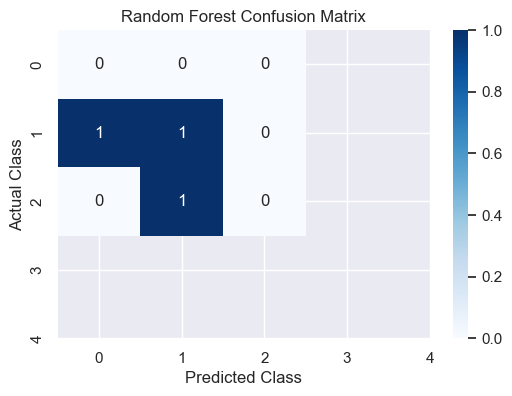

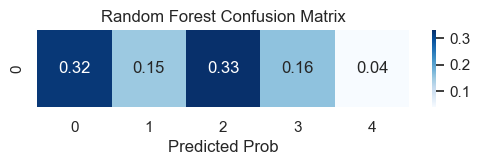

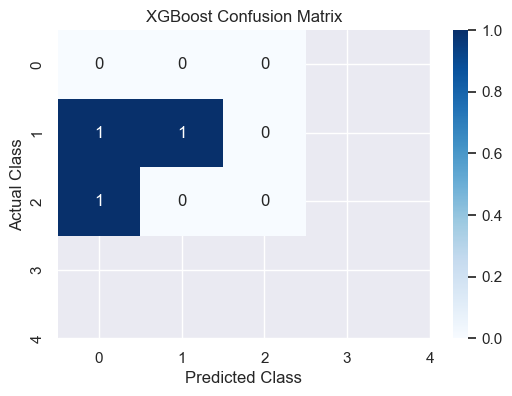

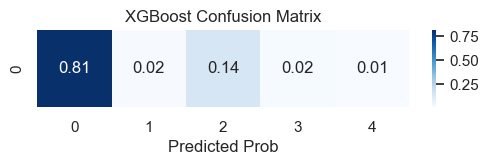

In [54]:
train_size = int(len(X) * 0.9)

X_train, y_train = X.iloc[:train_size], y.iloc[:train_size]
X_test, y_test = X.iloc[train_size:], y.iloc[train_size:]
#results = {}
for name, model in models.items():
    # Define the pipeline
    model_pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    
    # Train the model
    model_pipeline.fit(X_train, y_train)
    
    # Predictions
    y_pred = model_pipeline.predict(X_test)
    pred= model_pipeline.predict_proba(df_home_frw)

    plt.figure(figsize=(6,4))
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
    plt.xlabel("Predicted Class")
    plt.ylabel("Actual Class")
    plt.title(f"{name} Confusion Matrix")
    plt.show()
    plt.figure(figsize=(6,1))
    sns.heatmap(pred, annot=True, fmt='.2f', cmap='Blues', xticklabels=labels)
    plt.xlabel("Predicted Prob")
    plt.ylabel("")
    plt.title(f"{name} Confusion Matrix")
    plt.show()
    # Evaluate performance
    

### Model vs Home

In [55]:
target = "GAC"  # Goals For

# Separate features and target
X = df_home_ga.drop(columns=[target])
y = df_home_ga[target]
categorical_features = ["H/A"]  # Home/Away column
numerical_features = X.select_dtypes(include=[np.number]).columns.tolist()


In [56]:
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numerical_features),
    ("cat", OneHotEncoder(drop="first"), categorical_features)
])

In [57]:
models = {
    "Random Forest": RandomForestClassifier(n_estimators=100, max_depth=5, class_weight='balanced', random_state=42),
    "XGBoost": XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, objective='multi:softmax', 
                             num_class=6, eval_metric='mlogloss', random_state=42),
   # "LightGBM": LGBMRegressor(n_estimators=100, random_state=42),
   # "Linear Regression": LinearRegression()
}

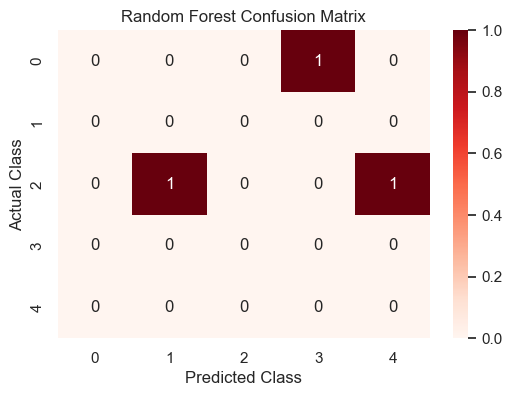

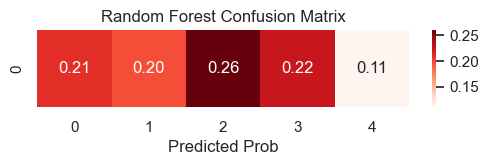

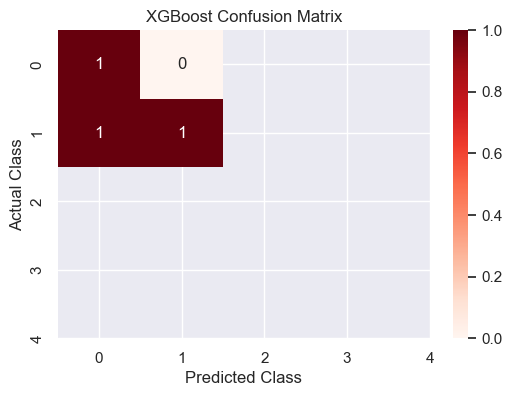

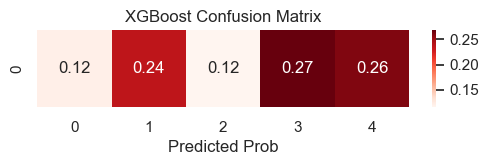

In [58]:
train_size = int(len(X) * 0.9)

X_train, y_train = X.iloc[:train_size], y.iloc[:train_size]
X_test, y_test = X.iloc[train_size:], y.iloc[train_size:]
#results = {}
for name, model in models.items():
    # Define the pipeline
    model_pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    
    # Train the model
    model_pipeline.fit(X_train, y_train)
    
    # Predictions
    y_pred = model_pipeline.predict(X_test)
    pred= model_pipeline.predict_proba(df_home_bcw)

    plt.figure(figsize=(6,4))
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Reds', xticklabels=labels, yticklabels=labels)
    plt.xlabel("Predicted Class")
    plt.ylabel("Actual Class")
    plt.title(f"{name} Confusion Matrix")
    plt.show()
    plt.figure(figsize=(6,1))
    sns.heatmap(pred, annot=True, fmt='.2f', cmap='Reds', xticklabels=labels)
    plt.xlabel("Predicted Prob")
    plt.ylabel("")
    plt.title(f"{name} Confusion Matrix")
    plt.show()
    # Evaluate performance
    

### Model Away

In [59]:
target = "GFC"  # Goals For

# Separate features and target
X = df_away_gf.drop(columns=[target])
y = df_away_gf[target]
categorical_features = ["H/A"]  # Home/Away column
numerical_features = X.select_dtypes(include=[np.number]).columns.tolist()


In [60]:
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numerical_features),
    ("cat", OneHotEncoder(drop="first"), categorical_features)
])

In [61]:
models = {
    "Random Forest": RandomForestClassifier(n_estimators=100, max_depth=5, class_weight='balanced', random_state=42),
    "XGBoost": XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, objective='multi:softmax', 
                             num_class=6, eval_metric='mlogloss', random_state=42),
   # "LightGBM": LGBMRegressor(n_estimators=100, random_state=42),
   # "Linear Regression": LinearRegression()
}

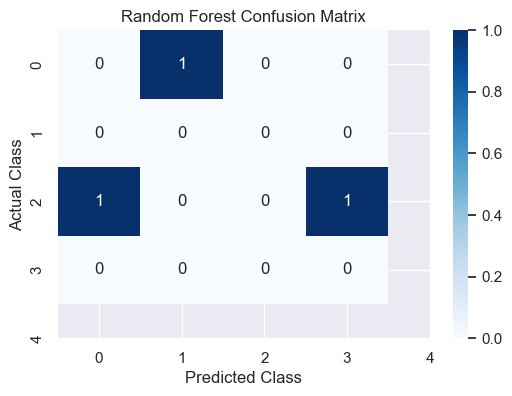

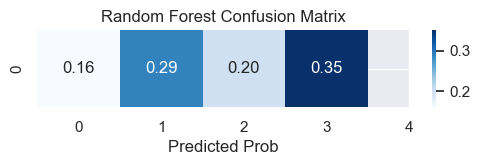

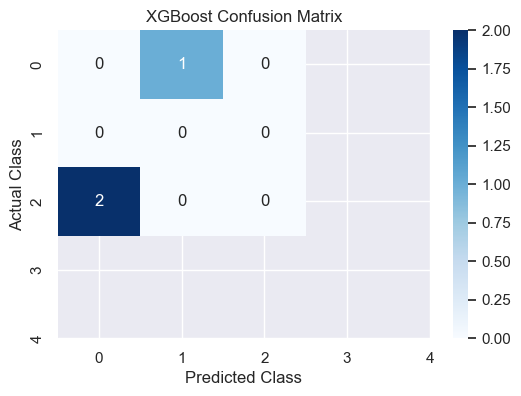

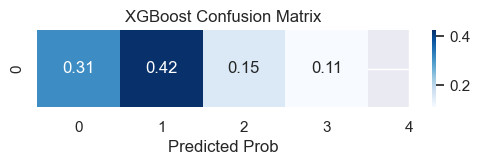

In [62]:
train_size = int(len(X) * 0.9)

X_train, y_train = X.iloc[:train_size], y.iloc[:train_size]
X_test, y_test = X.iloc[train_size:], y.iloc[train_size:]
#results = {}
for name, model in models.items():
    # Define the pipeline
    model_pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    
    # Train the model
    model_pipeline.fit(X_train, y_train)
    
    # Predictions
    y_pred = model_pipeline.predict(X_test)
    pred= model_pipeline.predict_proba(df_away_frw)

    plt.figure(figsize=(6,4))
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
    plt.xlabel("Predicted Class")
    plt.ylabel("Actual Class")
    plt.title(f"{name} Confusion Matrix")
    plt.show()
    plt.figure(figsize=(6,1))
    sns.heatmap(pred, annot=True, fmt='.2f', cmap='Blues', xticklabels=labels)
    plt.xlabel("Predicted Prob")
    plt.ylabel("")
    plt.title(f"{name} Confusion Matrix")
    plt.show()
    # Evaluate performance
    

### Model vs Away

In [63]:
target = "GAC"  # Goals For

# Separate features and target
X = df_away_ga.drop(columns=[target])
y = df_away_ga[target]
categorical_features = ["H/A"]  # Home/Away column
numerical_features = X.select_dtypes(include=[np.number]).columns.tolist()


In [64]:
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numerical_features),
    ("cat", OneHotEncoder(drop="first"), categorical_features)
])

In [65]:
models = {
    "Random Forest": RandomForestClassifier(n_estimators=100, max_depth=5, class_weight='balanced', random_state=42),
    "XGBoost": XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, objective='multi:softmax', 
                             num_class=6, eval_metric='mlogloss', random_state=42),
   # "LightGBM": LGBMRegressor(n_estimators=100, random_state=42),
   # "Linear Regression": LinearRegression()
}

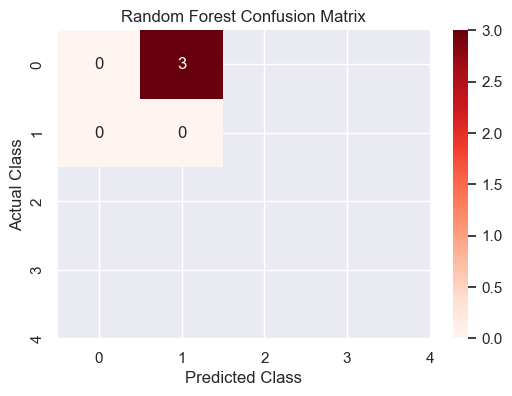

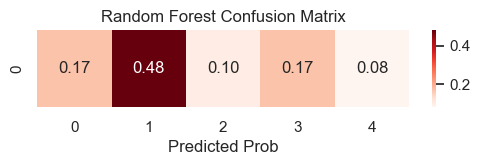

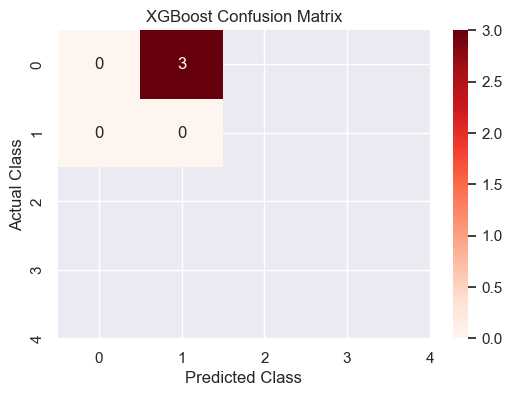

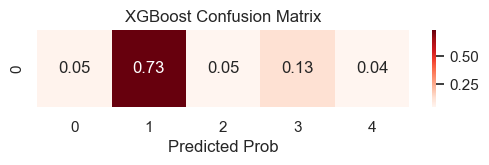

In [66]:
train_size = int(len(X) * 0.9)

X_train, y_train = X.iloc[:train_size], y.iloc[:train_size]
X_test, y_test = X.iloc[train_size:], y.iloc[train_size:]
#results = {}
for name, model in models.items():
    # Define the pipeline
    model_pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    
    # Train the model
    model_pipeline.fit(X_train, y_train)
    
    # Predictions
    y_pred = model_pipeline.predict(X_test)
    pred= model_pipeline.predict_proba(df_away_bcw)

    plt.figure(figsize=(6,4))
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Reds', xticklabels=labels, yticklabels=labels)
    plt.xlabel("Predicted Class")
    plt.ylabel("Actual Class")
    plt.title(f"{name} Confusion Matrix")
    plt.show()
    plt.figure(figsize=(6,1))
    sns.heatmap(pred, annot=True, fmt='.2f', cmap='Reds', xticklabels=labels)
    plt.xlabel("Predicted Prob")
    plt.ylabel("")
    plt.title(f"{name} Confusion Matrix")
    plt.show()
    # Evaluate performance
    

## Regression

### Model Home

In [67]:
target = "Tm_PTS"  # Goals For

# Separate features and target
X = df_home_gf.drop(columns=[target])
y = df_home_gf[target]
categorical_features = ["H/A"]  # Home/Away column
numerical_features = X.select_dtypes(include=[np.number]).columns.tolist()


In [68]:
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numerical_features),
    ("cat", OneHotEncoder(drop="first"), categorical_features)
])

In [69]:
model_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(n_estimators=20, random_state=25))
])

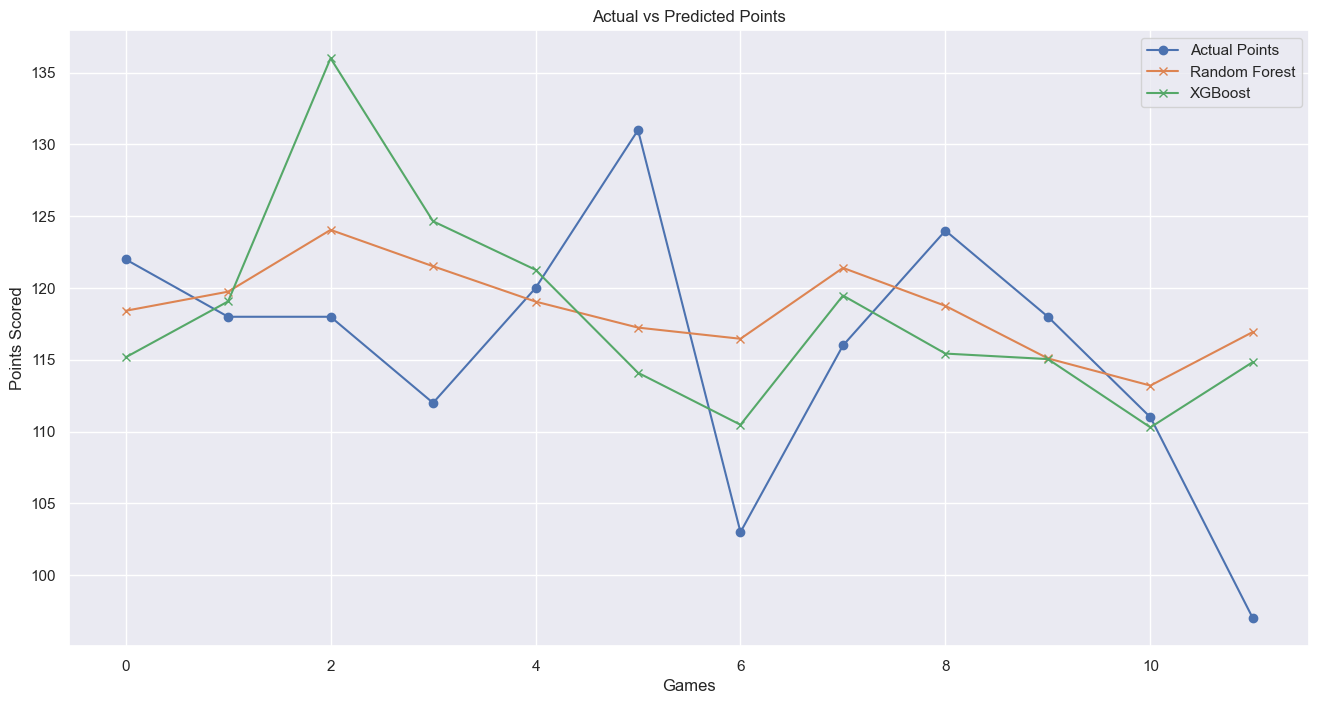

In [85]:
models = {
    "Random Forest": RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42),
    "XGBoost": XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42),
   # "LightGBM": LGBMRegressor(n_estimators=100, random_state=42),
   # "Linear Regression": LinearRegression()
}

# Split into training and testing sets
train_size = int(len(X) * 0.8)

X_train, y_train = X.iloc[:train_size], y.iloc[:train_size]
X_test, y_test = X.iloc[train_size:], y.iloc[train_size:]
# Train and evaluate each model
results = {}
plt.figure(figsize=(16,8))
plt.plot(y_test.values, label='Actual Points', marker='o')
for name, model in models.items():
    # Define the pipeline
    model_pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    
    # Train the model
    model_pipeline.fit(X_train, y_train)
    
    # Predictions
    y_pred = model_pipeline.predict(X_test)
    plt.plot(y_pred, label=name, marker='x')
    
    # Evaluate performance
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    pred= model_pipeline.predict(df_home_frw)
    
    results[name] = {"MAE": mae, "RMSE": rmse, "PRED": pred[0]}

# Convert results to a DataFrame and display
results_df = pd.DataFrame(results).T
plt.legend()
plt.title("Actual vs Predicted Points")
plt.xlabel("Games")
plt.ylabel("Points Scored")
plt.show()

In [80]:
results_df

,MAE,RMSE,PRED
Random Forest,7.063876,9.047376,117.443289
XGBoost,8.145854,10.362132,118.500099


### Model vs Home

In [48]:
target = "Opp_PTS"  # Goals For

# Separate features and target
X = df_home_ga.drop(columns=[target])
y = df_home_ga[target]
categorical_features = ["H/A"]  # Home/Away column
numerical_features = X.select_dtypes(include=[np.number]).columns.tolist()


In [49]:
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numerical_features),
    ("cat", OneHotEncoder(drop="first"), categorical_features)
])

In [50]:
model_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(n_estimators=20, random_state=25))
])

In [51]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=25)

# Train the model
model_pipeline.fit(X_train, y_train)

# Predictions
y_pred = model_pipeline.predict(X_test)

# Evaluate the model
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"MAE: {mae:.3f}")
print(f"RMSE: {rmse:.3f}")


MAE: 13.425
RMSE: 14.329


In [52]:
models = {
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "XGBoost": XGBRegressor(n_estimators=100, random_state=42),
    "LightGBM": LGBMRegressor(n_estimators=100, random_state=42),
    "Linear Regression": LinearRegression()
}

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=25)

# Train and evaluate each model
results = {}
for name, model in models.items():
    # Define the pipeline
    model_pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    
    # Train the model
    model_pipeline.fit(X_train, y_train)
    
    # Predictions
    y_pred = model_pipeline.predict(X_test)
    
    # Evaluate performance
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    pred= model_pipeline.predict(df_home_bcw)
    
    results[name] = {"MAE": mae, "RMSE": rmse, "PRED": pred}

# Convert results to a DataFrame and display
results_df = pd.DataFrame(results).T

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000991 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 6818
[LightGBM] [Info] Number of data points in the train set: 52, number of used features: 405
[LightGBM] [Info] Start training from score 108.211538
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain:

In [53]:
results_df

,MAE,RMSE,PRED
Random Forest,13.041667,13.840622,[108.75]
XGBoost,13.151134,15.03493,[113.32865]
LightGBM,16.852781,18.445559,[102.71760442340414]
Linear Regression,24.528301,25.202121,[84.73789959470245]


### Model Away

In [54]:
target = "Tm_PTS"  # Goals For

# Separate features and target
X = df_away_gf.drop(columns=[target])
y = df_away_gf[target]
categorical_features = ["H/A"]  # Home/Away column
numerical_features = X.select_dtypes(include=[np.number]).columns.tolist()


In [55]:
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numerical_features),
    ("cat", OneHotEncoder(drop="first"), categorical_features)
])

In [57]:
model_pipeline2 = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(n_estimators=20, random_state=25))
])

In [58]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=25)

# Train the model
model_pipeline2.fit(X_train, y_train)

# Predictions
y_pred = model_pipeline2.predict(X_test)

# Evaluate the model
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"MAE: {mae:.3f}")
print(f"RMSE: {rmse:.3f}")


MAE: 12.708
RMSE: 14.490


In [59]:
models = {
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "XGBoost": XGBRegressor(n_estimators=100, random_state=42),
    "LightGBM": LGBMRegressor(n_estimators=100, random_state=42),
    "Linear Regression": LinearRegression()
}

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=25)

# Train and evaluate each model
results = {}
for name, model in models.items():
    # Define the pipeline
    model_pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    
    # Train the model
    model_pipeline.fit(X_train, y_train)
    
    # Predictions
    y_pred = model_pipeline.predict(X_test)
    
    # Evaluate performance
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    pred= model_pipeline.predict(df_away_frw)
    
    results[name] = {"MAE": mae, "RMSE": rmse, "PRED": pred}

# Convert results to a DataFrame and display
results_df = pd.DataFrame(results).T

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000461 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6654
[LightGBM] [Info] Number of data points in the train set: 51, number of used features: 405
[LightGBM] [Info] Start training from score 121.941176
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain,

In [60]:
results_df

,MAE,RMSE,PRED
Random Forest,14.915,16.475376,[120.74]
XGBoost,12.521159,13.834184,[121.489395]
LightGBM,13.837515,17.031631,[126.221659266553]
Linear Regression,14.006226,16.370987,[137.60611314295068]


### Model vs Away

In [61]:
target = "Opp_PTS"  # Goals For

# Separate features and target
X = df_away_ga.drop(columns=[target])
y = df_away_ga[target]
categorical_features = ["H/A"]  # Home/Away column
numerical_features = X.select_dtypes(include=[np.number]).columns.tolist()


In [62]:
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numerical_features),
    ("cat", OneHotEncoder(drop="first"), categorical_features)
])

In [63]:
model_pipeline2 = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(n_estimators=20, random_state=25))
])

In [64]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=25)

# Train the model
model_pipeline2.fit(X_train, y_train)

# Predictions
y_pred = model_pipeline2.predict(X_test)

# Evaluate the model
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"MAE: {mae:.3f}")
print(f"RMSE: {rmse:.3f}")


MAE: 10.350
RMSE: 11.309


In [65]:
models = {
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "XGBoost": XGBRegressor(n_estimators=100, random_state=42),
    "LightGBM": LGBMRegressor(n_estimators=100, random_state=42),
    "Linear Regression": LinearRegression()
}

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=25)

# Train and evaluate each model
results = {}
for name, model in models.items():
    # Define the pipeline
    model_pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    
    # Train the model
    model_pipeline.fit(X_train, y_train)
    
    # Predictions
    y_pred = model_pipeline.predict(X_test)
    
    # Evaluate performance
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    pred= model_pipeline.predict(df_away_bcw)
    
    results[name] = {"MAE": mae, "RMSE": rmse, "PRED": pred}

# Convert results to a DataFrame and display
results_df = pd.DataFrame(results).T

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000408 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6692
[LightGBM] [Info] Number of data points in the train set: 51, number of used features: 405
[LightGBM] [Info] Start training from score 110.666667
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain,

In [66]:
results_df

,MAE,RMSE,PRED
Random Forest,11.596667,12.906048,[108.99]
XGBoost,15.120514,16.820382,[102.5551]
LightGBM,9.838286,11.897321,[109.56588285586935]
Linear Regression,14.973625,19.146221,[86.82162740707135]
